In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/social_media_addiction_greece.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/social_media_addiction_greece.csv'

In [2]:
import pandas as pd

df = pd.read_csv('data/raw/social_media_addiction_greece.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/social_media_addiction_greece.csv'

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/social_media_addiction_greece.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/social_media_addiction_greece.csv'

In [4]:
import os
os.getcwd()

'/Users/django/Desktop/Data Analysis/Projects/social-media-addiction-greece-python-analysis/notebooks'

In [5]:
import pandas as pd

df = pd.read_csv('../data/raw/social_media_addiction_greece.csv')

df.head()

,respondent_id,age,gender,region,occupation,primary_platform,daily_usage_hours,sleep_hours,anxiety_score,productivity_score,relationship_impact,academic_work_impact,social_comparison_score,addiction_score,wants_to_reduce_usage
0,1,22,Male,Athens,Student,Instagram,5.5,6.5,7,6,5,6,8,7,Yes
1,2,28,Female,Thessaloniki,Employee,Facebook,3.0,7.5,5,7,4,5,6,5,No
2,3,19,Female,Patras,Student,TikTok,6.5,5.5,8,5,6,7,9,8,Yes
3,4,35,Male,Heraklion,Self-employed,YouTube,4.0,6.0,6,6,5,5,6,6,No
4,5,24,Male,Athens,Student,Instagram,7.0,5.0,9,4,7,8,9,9,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   respondent_id            10 non-null     int64  
 1   age                      10 non-null     int64  
 2   gender                   10 non-null     str    
 3   region                   10 non-null     str    
 4   occupation               10 non-null     str    
 5   primary_platform         10 non-null     str    
 6   daily_usage_hours        10 non-null     float64
 7   sleep_hours              10 non-null     float64
 8   anxiety_score            10 non-null     int64  
 9   productivity_score       10 non-null     int64  
 10  relationship_impact      10 non-null     int64  
 11  academic_work_impact     10 non-null     int64  
 12  social_comparison_score  10 non-null     int64  
 13  addiction_score          10 non-null     int64  
 14  wants_to_reduce_usage    10 non-null    

In [7]:
df.describe()

,respondent_id,age,daily_usage_hours,sleep_hours,anxiety_score,productivity_score,relationship_impact,academic_work_impact,social_comparison_score,addiction_score
count,10.00000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,26.900000,4.650000,6.20000,6.200000,6.000000,4.900000,5.800000,7.000000,6.300000
std,3.02765,5.321863,2.028272,1.00554,2.043961,1.632993,1.791957,1.813529,1.943651,2.213594
min,1.00000,19.000000,2.000000,4.50000,3.000000,3.000000,2.000000,3.000000,4.000000,3.000000
25%,3.25000,22.500000,3.125000,5.62500,5.000000,5.250000,4.000000,5.000000,6.000000,5.000000
50%,5.50000,27.500000,4.250000,6.25000,6.000000,6.000000,5.000000,5.500000,6.500000,6.000000
75%,7.75000,30.500000,6.250000,6.87500,7.750000,7.000000,5.750000,6.750000,8.750000,7.750000
max,10.00000,35.000000,8.000000,7.50000,9.000000,8.000000,8.000000,9.000000,10.000000,10.000000


In [8]:
df['primary_platform'].value_counts()

primary_platform
Instagram    3
Facebook     3
TikTok       2
YouTube      1
Twitter      1
Name: count, dtype: int64

In [9]:
df.groupby('primary_platform')['addiction_score'].mean().sort_values(ascending=False)

primary_platform
TikTok       9.000000
Instagram    7.333333
YouTube      6.000000
Twitter      5.000000
Facebook     4.000000
Name: addiction_score, dtype: float64

In [10]:
df[['daily_usage_hours', 'addiction_score']].corr()

,daily_usage_hours,addiction_score
daily_usage_hours,1.000000,0.991142
addiction_score,0.991142,1.000000


## Initial Insights

Initial analysis of the dataset showed that Instagram and Facebook were the most frequently used platforms in the sample, followed by TikTok.

However, platform frequency did not necessarily match addiction intensity. TikTok recorded the highest average addiction score (9.0), followed by Instagram (7.33), while Facebook had the lowest average addiction score (4.0).

In addition, the correlation between daily usage hours and addiction score was extremely strong (0.99), suggesting that higher time spent on social media was closely associated with higher addiction levels in this sample.

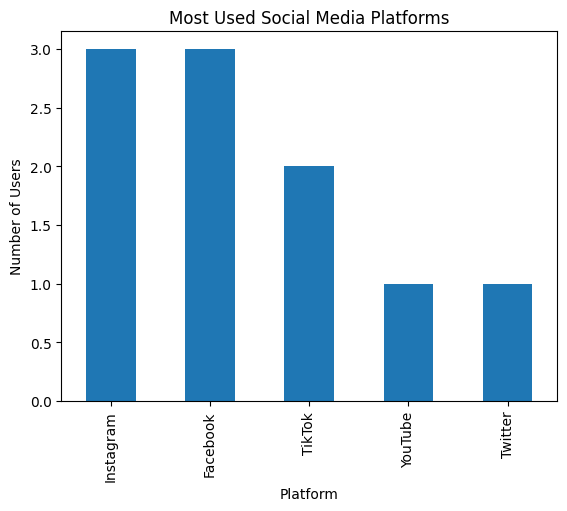

In [11]:
import matplotlib.pyplot as plt

df['primary_platform'].value_counts().plot(kind='bar')
plt.title('Most Used Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.show()

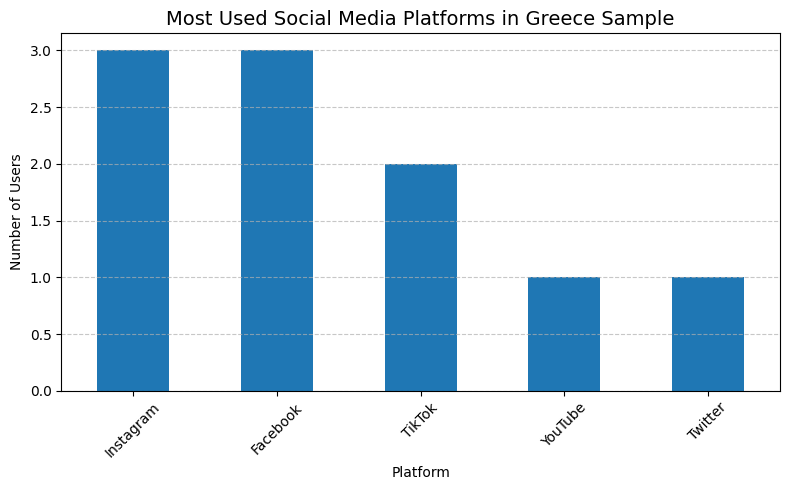

In [12]:
import matplotlib.pyplot as plt

platform_counts = df['primary_platform'].value_counts()

plt.figure(figsize=(8,5))
platform_counts.plot(kind='bar')

plt.title('Most Used Social Media Platforms in Greece Sample', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Number of Users')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

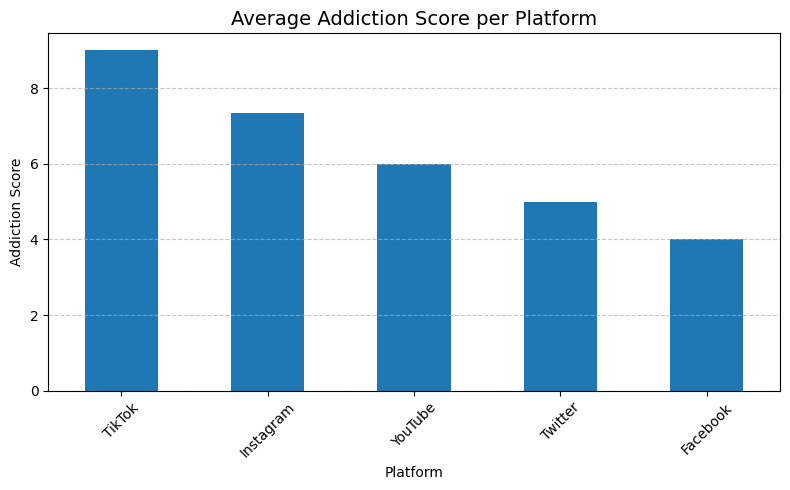

In [13]:
plt.figure(figsize=(8,5))

df.groupby('primary_platform')['addiction_score'].mean().sort_values(ascending=False).plot(kind='bar')

plt.title('Average Addiction Score per Platform', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Addiction Score')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

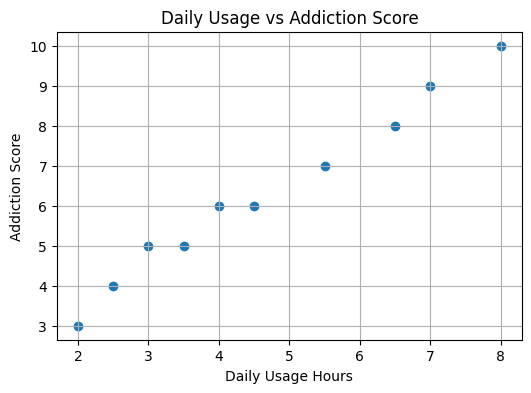

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(df['daily_usage_hours'], df['addiction_score'])

plt.title('Daily Usage vs Addiction Score')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Addiction Score')

plt.grid(True)
plt.show()

In [15]:
plt.style.use('seaborn-v0_8')

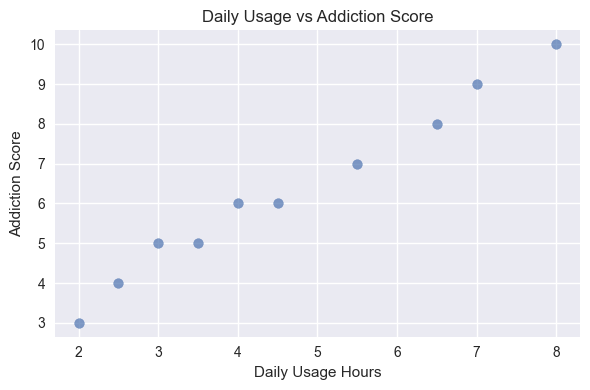

In [16]:
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(6,4))
plt.scatter(df['daily_usage_hours'], df['addiction_score'], alpha=0.7)

plt.title('Daily Usage vs Addiction Score')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Addiction Score')

plt.grid(True)
plt.tight_layout()
plt.show()

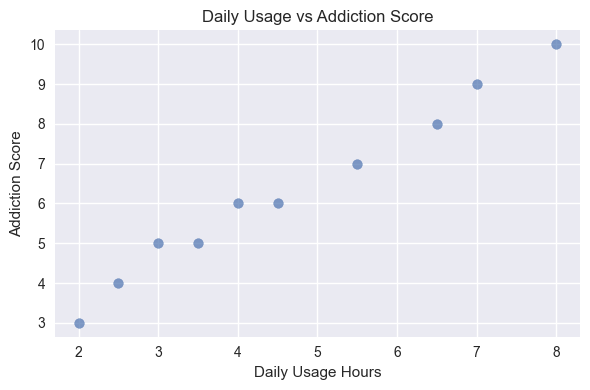

In [17]:
import matplotlib.pyplot as plt

# style
plt.style.use('seaborn-v0_8')

# plot
plt.figure(figsize=(6,4))
plt.scatter(df['daily_usage_hours'], df['addiction_score'], alpha=0.7)

# labels & title
plt.title('Daily Usage vs Addiction Score')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Addiction Score')

# grid & layout
plt.grid(True)
plt.tight_layout()

# SAVE (πριν το show!)
plt.savefig('../images/addiction_scatter.png', dpi=300)

# show
plt.show()